# 03a: Build the analysis cohort

Create one auditable eligibility row per telemetry site.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

HERE = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (HERE, *HERE.parents) if (p/'src'/'ausgrid_analysis').is_dir()), None)
assert PROJECT_ROOT is not None, 'Start Jupyter inside the ausgrid_analysis project.'
sys.path.insert(0, str(PROJECT_ROOT/'src'))
from ausgrid_analysis.analysis_cohort import CohortRules, build_site_eligibility, site_eligibility_path
from ausgrid_analysis.config import load_config
from ausgrid_analysis.db import connect
from ausgrid_analysis.schemas import sql_string
pd.set_option('display.max_columns', 100); plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
CONFIG_PATH = PROJECT_ROOT/'analysis.toml'
OVERWRITE_COHORT = False
MINIMUM_P_Q_COVERAGE = 0.95
ACCEPTED_MAPPING_CONFIDENCE = ('high', 'medium')
config = load_config(CONFIG_PATH, check_inputs=False)
scope = config.scope(None, None)
rules = CohortRules(
    minimum_power_coverage=MINIMUM_P_Q_COVERAGE,
    accepted_mapping_confidence=ACCEPTED_MAPPING_CONFIDENCE,
    require_explicit_no_controlled_load=True,
    require_location=True,
)
print(rules)

CohortRules(minimum_power_coverage=0.95, accepted_mapping_confidence=('high', 'medium'), require_explicit_no_controlled_load=True, require_location=True)


In [3]:
output = site_eligibility_path(config)
if OVERWRITE_COHORT or not output.is_file():
    summary = build_site_eligibility(config, scope, rules=rules, overwrite=OVERWRITE_COHORT)
    display(pd.DataFrame([summary]).T.rename(columns={0:'value'}))
else:
    print('Reusing existing site eligibility. Set OVERWRITE_COHORT=True to rebuild.')
con = connect(config)
eligibility = con.execute(f'SELECT * FROM read_parquet({sql_string(output)}) ORDER BY serial').fetchdf()
display(eligibility.head())

,value
created_utc,2026-07-31T03:32:11.612594+00:00
scope,full
minimum_power_coverage,0.95
accepted_mapping_confidence,"[high, medium]"
sites,1342
solar_only_sites,927
controlled_load_yes_sites,62
eligible_for_irradiance_assessment,414
eligible_for_decomposition_experiment,414
output,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...


,serial,metadata_available,analysis_cohort,has_battery,install_phase_count,observed_phase_count,observed_phases,power_phase_count,power_available_phases,inferred_der_phases,phase_mapping_method,phase_mapping_confidence,phase_mapping_sign_dependency,phase_mapping_requires_review,phase_mapping_margin_ratio,top_solar_signature_w,phase_mapping_assessable,solar_only_mapped_cohort,measurement_basis,voltage_measurement_location,formal_inverter_conformance_assessable,controlled_load,sub_lat,sub_long,solar_capacity_kw,approved_capacity_kw,s_rated_kva,s_rated_source,controlled_load_status,has_controlled_load,inferred_der_phase_count_observed,minimum_active_power_coverage,minimum_reactive_power_coverage,minimum_joint_power_coverage,p_q_missingness_mismatch_rows,gate_solar_only,gate_no_battery,gate_no_controlled_load,gate_mapping,gate_power_coverage,gate_location,gate_capacity_available,eligible_for_irradiance_assessment,eligible_for_decomposition_experiment,exclusion_reasons
0,326214487,True,solar_only,False,3.0,3,A|B|C,3,A|B|C,A|B|C,all_power_available_phases,high,not_sign_ranked,True,NaN,NaN,True,True,net_meter,revenue_meter,False,No,-33.673482,151.317168,6.300,10.0,NaN,unavailable,no,False,3,1.0,1.0,1.0,0,True,True,True,True,True,True,True,True,True,
1,326214520,True,solar_only,False,3.0,3,A|B|C,3,A|B|C,A|B|C,all_power_available_phases,high,not_sign_ranked,True,NaN,NaN,True,True,net_meter,revenue_meter,False,No,-33.773266,151.258623,8.715,10.0,NaN,unavailable,no,False,3,1.0,1.0,1.0,0,True,True,True,True,True,True,True,True,True,
2,326228801,True,solar_battery,True,3.0,1,A,0,,,insufficient_power_phases,insufficient,not_sign_ranked,True,NaN,NaN,False,False,net_meter,revenue_meter,False,No,-33.924673,151.147256,9.620,30.0,NaN,unavailable,no,False,0,0.0,0.0,0.0,0,False,False,True,False,False,True,True,False,False,not_solar_only|battery|mapping_not_accepted|in...
3,326612333,True,solar_battery,True,3.0,1,A,0,,,insufficient_power_phases,insufficient,not_sign_ranked,True,NaN,NaN,False,False,net_meter,revenue_meter,False,No,-33.780617,151.200748,11.040,30.0,NaN,unavailable,no,False,0,0.0,0.0,0.0,0,False,False,True,False,False,True,True,False,False,not_solar_only|battery|mapping_not_accepted|in...
4,361431370,True,solar_only,False,1.0,1,A,0,,,insufficient_power_phases,insufficient,not_sign_ranked,True,NaN,NaN,False,False,net_meter,revenue_meter,False,No,-34.037521,151.003009,6.640,10.0,NaN,unavailable,no,False,0,0.0,0.0,0.0,0,True,True,True,False,False,True,True,False,False,mapping_not_accepted|insufficient_p_q_coverage


## Gate accounting

In [4]:
gates = [c for c in eligibility.columns if c.startswith('gate_')]
gate_counts = pd.DataFrame({
    'gate': gates,
    'passed_sites': [int(eligibility[c].sum()) for c in gates],
    'failed_sites': [int((~eligibility[c]).sum()) for c in gates],
})
display(gate_counts)
display(eligibility.groupby(['analysis_cohort','controlled_load_status','phase_mapping_confidence'], dropna=False).size().rename('n_sites').reset_index())
display(eligibility['exclusion_reasons'].value_counts(dropna=False).rename_axis('exclusion_reasons').reset_index(name='n_sites').head(25))

,gate,passed_sites,failed_sites
0,gate_solar_only,927,415
1,gate_no_battery,987,355
2,gate_no_controlled_load,1220,122
3,gate_mapping,647,695
4,gate_power_coverage,668,674
5,gate_location,1282,60
6,gate_capacity_available,1282,60


,analysis_cohort,controlled_load_status,phase_mapping_confidence,n_sites
0,solar_battery,no,high,177
1,solar_battery,no,insufficient,155
2,solar_battery,no,low,5
3,solar_battery,no,medium,4
4,solar_battery,yes,high,13
5,solar_battery,yes,insufficient,1
6,solar_only,no,high,408
7,solar_only,no,insufficient,452
8,solar_only,no,low,13
9,solar_only,no,medium,6


,exclusion_reasons,n_sites
0,mapping_not_accepted|insufficient_p_q_coverage,452
1,,414
2,not_solar_only|battery,181
3,not_solar_only|battery|mapping_not_accepted|in...,155
4,not_solar_only|controlled_load_or_unknown|mapp...,60
5,controlled_load_or_unknown,39
6,not_solar_only|battery|controlled_load_or_unknown,13
7,mapping_not_accepted,13
8,controlled_load_or_unknown|mapping_not_accepte...,6
9,not_solar_only|battery|mapping_not_accepted,5


,minimum_active_power_coverage,minimum_reactive_power_coverage,minimum_joint_power_coverage
count,1342.000000,1342.000000,1342.000000
mean,0.497765,0.497765,0.497765
std,0.500181,0.500181,0.500181
min,0.000000,0.000000,0.000000
1%,0.000000,0.000000,0.000000
5%,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000
95%,1.000000,1.000000,1.000000


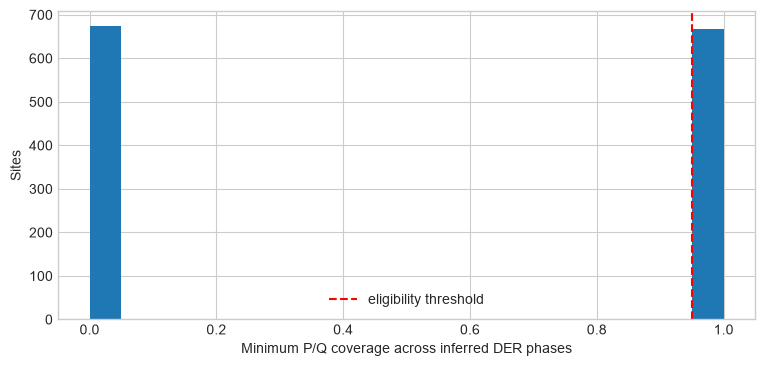

In [6]:
coverage = eligibility[['minimum_active_power_coverage','minimum_reactive_power_coverage','minimum_joint_power_coverage']]
display(coverage.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))
fig, ax = plt.subplots(figsize=(9,4))
eligibility.minimum_joint_power_coverage.hist(ax=ax, bins=20)
ax.axvline(MINIMUM_P_Q_COVERAGE, color='red', linestyle='--', label='eligibility threshold')
ax.set(xlabel='Minimum P/Q coverage across inferred DER phases', ylabel='Sites')
ax.legend(); plt.show()

## Final cohort gate

In [7]:
eligible = eligibility.loc[eligibility.eligible_for_irradiance_assessment].copy()
display(eligible[['serial','inferred_der_phases','phase_mapping_method','phase_mapping_confidence','minimum_joint_power_coverage','controlled_load_status','sub_lat','sub_long','solar_capacity_kw']].head(30))
print('Eligible for irradiance assessment:', len(eligible))
assert eligibility.serial.is_unique
assert eligible.analysis_cohort.eq('solar_only').all()
assert (~eligible.has_battery).all()
assert eligible.controlled_load_status.eq('no').all()
assert eligible.minimum_joint_power_coverage.ge(MINIMUM_P_Q_COVERAGE).all()
assert eligible[['sub_lat','sub_long']].notna().all().all()
con.close()
print('Analysis cohort gate passed.')

,serial,inferred_der_phases,phase_mapping_method,phase_mapping_confidence,minimum_joint_power_coverage,controlled_load_status,sub_lat,sub_long,solar_capacity_kw
0,326214487,A|B|C,all_power_available_phases,high,1.0,no,-33.673482,151.317168,6.300
1,326214520,A|B|C,all_power_available_phases,high,1.0,no,-33.773266,151.258623,8.715
15,810041617,A|B|C,all_power_available_phases,high,1.0,no,-33.246447,151.482533,10.375
16,810041664,A|B|C,all_power_available_phases,high,1.0,no,-32.905531,151.612190,13.200
20,810058521,A|B|C,all_power_available_phases,high,1.0,no,-32.770614,151.589482,6.640
39,810126096,C,ranked_local_day_night_export_signature,medium,1.0,no,-34.051479,151.136683,13.280
41,810126441,A|B|C,all_power_available_phases,high,1.0,no,-34.054889,151.117117,13.280
44,810140608,A,ranked_local_day_night_export_signature,high,1.0,no,-34.066605,151.001654,9.545
45,810140651,A|B|C,all_power_available_phases,high,1.0,no,-32.700648,151.569453,7.880
46,810140828,B,ranked_local_day_night_export_signature,high,1.0,no,-32.760277,151.623747,9.960


Eligible for irradiance assessment: 414
Analysis cohort gate passed.
